# Práctica 2. Propiedades Estadísticas del Lenguaje y Diversidad.
### Lingüística Computacional 2026-2
#### Cuerpo Académico
**Dra.** María Ximena Gutiérrez Vasques

**Ayud.** Ximena de la Luz Contreras Mendoza

**Lab.** Diego Alberto Barriga Martínez

#### Alumno
Toporek Coca Eric - **314284987**

## Verificación de la ley de Zipf

En primera instancia, se necesita crear un lenguaje artificial, por lo que definiremos la siguiente función:


In [1]:
import random
import string

def generate_artificial_language(alphabet: str = string.ascii_lowercase, 
                                 num_words: int = 100, 
                                 min_length: int = 3, 
                                 max_length: int = 10) -> list[str]:
    """
    Generates an artificial language of random 'words' using a specific alphabet.
    
    Parameters:
    - alphabet (str): The set of characters to choose from (default is a-z).
    - num_words (int): The number of meaningless words to generate.
    - min_length (int): Minimum length of a generated word.
    - max_length (int): Maximum length of a generated word.
    
    Returns:
    - list[str]: A list of randomly generated strings.
    """
    language = []
    
    for _ in range(num_words):
        # Pick a random length for the current word
        word_length = random.randint(min_length, max_length)
        
        # Generate the word by randomly choosing characters from the alphabet
        random_word = "".join(random.choice(alphabet) for _ in range(word_length))
        
        language.append(random_word)
        
    return language

# Example usage:
# Generate 5 words using only the characters 'a', 'b', 'c', 'd' and 'e'
# with lengths between 4 and 7 characters.
my_fake_language = generate_artificial_language(alphabet="abcde", num_words=5, min_length=4, max_length=7)

print(my_fake_language)
# Output might look like: ['ebad', 'cabeea', 'acbd', 'ddeadca', 'babd']


['abcbb', 'cbede', 'adcd', 'cbdabe', 'acbda']


Antes de proceder con el análisis cuantitativo de el idioma generado artificialmente, importaremos un corpus de una lengua de bajos recursos digitales, con ayuda del paquete `py_etotl`

In [2]:
%pip install elotl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 8.5 MB/s  0:00:00m eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import elotl.corpus
print("Name\t\tDescription")
list_of_corpus = elotl.corpus.list_of_corpus()
for row in list_of_corpus:
    print(row)

Name		Description
['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
['tsunkua', 'Is a Spanish-Otomí parallel corpus']
['kolo', 'Is a Spanish-Mixteco parallel corpus']


En consideración de cuál lengua es la que tiene el menor número de hablantes de acuerdo al último censo [^1], seleccionaremos el otomí para trabajar con él. 

[^1]: https://cuentame.inegi.org.mx/descubre/poblacion/hablantes_de_lengua_indigena/

In [8]:
tsunkua = elotl.corpus.load("tsunkua")
print(f"Longitud del Corpus Otomí: {len(tsunkua)}")
print (f"Muestra de una entrada en el corpus paralelo: \n\n{"\n".join(tsunkua[0])}")

Longitud del Corpus Otomí: 4963
Muestra de una entrada en el corpus paralelo: 

Arde, se calcina su corazón y su cuerpo está doliente. De igual modo a mí me arde y se calcina mi corazón.
Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa ñ'u̱. Mahye̱gi nugi zo̱ ne da zät'i ma ndäte.
Otomí del Mezquital (ote)
Visión de los vencidos (hñahñu)
visiondelosvencidoshnahnu.pdf
5c8a6eb3656c6f188d010000


El corpus conforma cerca de 5 mil oraciones y está estructurado en 5 componentes, dónde el segundo es el lenguaje original, de acuerdo a la documentación del paquete [^2]. Por lo tanto así se extraerá y será juntado en un gran campo de texto, únicamente que, al enfrentarnos con distintas variantes de una misma lengua, se hará un breve análisis exploratorio de datos.  

[^2]: https://github.com/ElotlMX/py-elotl/tree/master

In [10]:
import pandas as pd
columns = ['Español', 'Otomí', 'Variante', 'Fuente','doc','id']
tsunkua_df = pd.DataFrame(data = tsunkua, columns=columns)
tsunkua_df.head()

,Español,Otomí,Variante,Fuente,doc,id
0,"Arde, se calcina su corazón y su cuerpo está d...","Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa...",Otomí del Mezquital (ote),Visión de los vencidos (hñahñu),visiondelosvencidoshnahnu.pdf,5c8a6eb3656c6f188d010000
1,"Luego ya vienen, de nuevo vienen en seguimient...",Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱ ra t...,Otomí del Mezquital (ote),Visión de los vencidos (hñahñu),visiondelosvencidoshnahnu.pdf,5c8a6eb3656c6f188d010000
2,"y mirad que no lo descubráis a hijo de madre, ...","y mirad que no lo descubráis a hijo de madre, ...",Otomí del Mezquital (ote),Visión de los vencidos (hñahñu),visiondelosvencidoshnahnu.pdf,5c8a6eb3656c6f188d010000
3,En este tiempo viene una embajada del rg de Ac...,"Di geb'u̱, ba ehe̱ n'a ra m'e̱hni ra bo̱nahmu ...",Otomí del Mezquital (ote),Visión de los vencidos (hñahñu),visiondelosvencidoshnahnu.pdf,5c8a6eb3656c6f188d010000
4,"Por cierto serás esclava, serás persona de otro:","""Nu'a dra t'o̱t'ai ra b'e̱go, gri j'äi ma n'a:",Otomí del Mezquital (ote),Visión de los vencidos (hñahñu),visiondelosvencidoshnahnu.pdf,5c8a6eb3656c6f188d010000


In [ ]:
tsunkua_df = tsunkua_df.drop(columns=['Fuente', 'doc', 'id'])
tsunkua_df.groupby('Variante').size()

Variante
Acambay, Edomex (ots)                 15
Ixtenco (otz)                         25
Otomí del Estado de México (ots)    1475
Otomí del Mezquital (ote)           3448
dtype: int64

Con fines de homogeneidad tomaremos la variante con mayor cuenta de elementos, que es el Otomí del Mezquital (ote)

In [ ]:
tsunkua_ote = tsunkua_df[tsunkua_df['Variante'] == 'Otomí del Mezquital (ote)']


,Español,Otomí,Variante
0,"Arde, se calcina su corazón y su cuerpo está d...","Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa...",Otomí del Mezquital (ote)
1,"Luego ya vienen, de nuevo vienen en seguimient...",Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱ ra t...,Otomí del Mezquital (ote)
2,"y mirad que no lo descubráis a hijo de madre, ...","y mirad que no lo descubráis a hijo de madre, ...",Otomí del Mezquital (ote)
3,En este tiempo viene una embajada del rg de Ac...,"Di geb'u̱, ba ehe̱ n'a ra m'e̱hni ra bo̱nahmu ...",Otomí del Mezquital (ote)
4,"Por cierto serás esclava, serás persona de otro:","""Nu'a dra t'o̱t'ai ra b'e̱go, gri j'äi ma n'a:",Otomí del Mezquital (ote)


Finalmente, obtendremos nuestro corpus de la columna Otomí.

In [19]:
import string
corpus = " ".join(tsunkua_ote['Otomí'].to_list())
## Limpieza del corpus
translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))

clean_otomi_corpus = corpus.translate(translator)
clean_otomi_corpus = " ".join(clean_otomi_corpus.split())
clean_otomi_corpus[:100]

'Zo̱ da zot i ri ndäte ne ri ngo̱k ei yabu̱ xa ñ u̱ Mahye̱gi nugi zo̱ ne da zät i ma ndäte Ebu̱ ba eh'

In [20]:
## generacion del corpus artificial, que tenga una longitud similar
otomi_word_list = clean_otomi_corpus.lower().split()
print(f"Num de palabras en Corpus Otomí: {len(otomi_word_list)}")

Num de palabras en Corpus Otomí: 65119


In [21]:
artificial_random_corpus = generate_artificial_language(num_words=65119,min_length=2)

In [ ]:
## Usando counters para asumir las frecuencias
from collections import Counter

otomi_counter = Counter(otomi_word_list)
artificial_counter = Counter(artificial_random_corpus)

#otomi_counter.most_common(15)
#artificial_counter.most_common(15)

[('ra', 5138),
 ('ya', 3466),
 ('a', 2545),
 ('bi', 2119),
 ('mi', 1740),
 ('i', 1674),
 ('ne', 1111),
 ('da', 1031),
 ('b', 962),
 ('ha', 937),
 ('n', 891),
 ('ge', 815),
 ('nu', 814),
 ('u̱', 741),
 ('ma', 733)]

In [24]:
def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [ ]:
import numpy as np
from scipy.optimize import minimize


def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    """
    Calculate the sum of squared errors for Zipf's law fit.

    Parameters
    ----------
    alpha : np.float64
        The exponent parameter to optimize in Zipf's law
    word_ranks : np.ndarray
        Array of word ranks (1 = most frequent word)
    word_frequencies : np.ndarray
        Array of observed word frequencies

    Returns
    -------
    np.float64
        Sum of squared errors between log frequencies and Zipf's law prediction
    """
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [29]:
def get_plot_values(df):
    # Obtenemos los ranks y las frecuencias del corpus
    # +1 para hacer que los ranks inicien en 1 y no en 0
    ranks = np.array(df.index) + 1
    frequencies = np.array(df["count"])

    # Parámeto alfa inicial
    initial_alpha_guess = 1.0

    optimization_result = minimize(
        zipf_minimization_objective, initial_alpha_guess, args=(ranks, frequencies)
    )
    estimated_alpha = optimization_result.x[0]

    mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, frequencies)

    return ranks,frequencies,estimated_alpha,mean_squared_error

In [28]:
def plot_generate_zipf(alpha: np.float64, ranks: np.ndarray, freqs: np.ndarray) -> None:
    plt.plot(
        np.log(ranks),
        np.log(freqs[0]) - alpha * np.log(ranks),
        color="r",
        label="Aproximación Zipf",
    )

In [30]:
otomi_freq_df = counter_to_pandas(otomi_counter)
artificial_freq_df = counter_to_pandas(artificial_counter)



Alpha:  0.30924735309993284


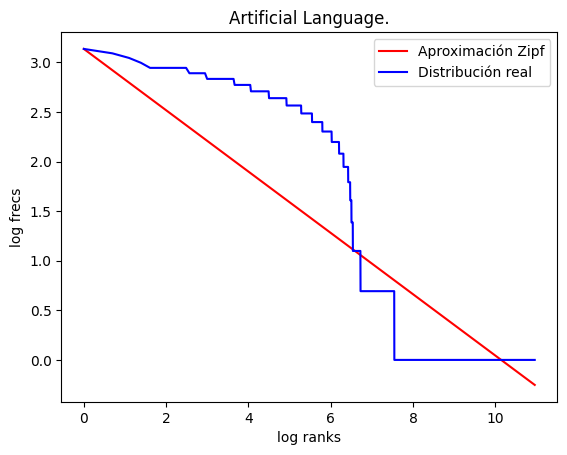

In [37]:
import matplotlib.pyplot as plt

values = get_plot_values(artificial_freq_df)
print("Alpha: ", values[2])
plot_generate_zipf(values[2], values[0], values[1])
plt.plot(np.log(values[0]), np.log(values[1]), color="b", label="Distribución real")
plt.title("Artificial Language.")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Alpha: 1.0315686303208764


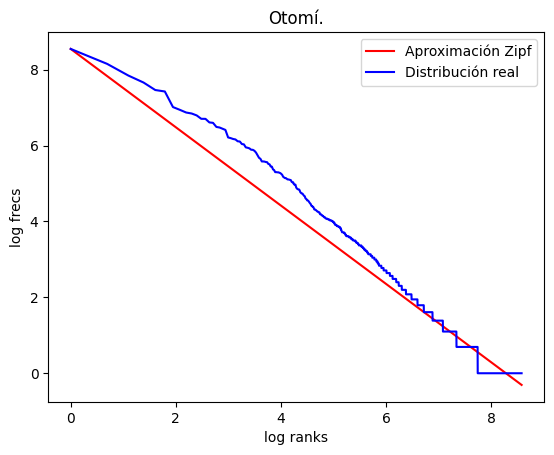

In [36]:
import matplotlib.pyplot as plt

values = get_plot_values(otomi_freq_df)
print(f"Alpha: {values[2]}")
plot_generate_zipf(values[2], values[0], values[1])
plt.plot(np.log(values[0]), np.log(values[1]), color="b", label="Distribución real")
#plt.plot(values[1],color = "g", label = "Frecuencias")
plt.title("Otomí.")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### Observaciones

Podemos notar que la Ley de Zipf es parcialmente correcta para lenguas generadas de manera pseudoaleatoria como el texto generado artificialmente por cadenas aleatorias, donde su comportamiento es menos "orgánico" que un lenguaje natural, en el caso del Otomí, a pesar de tener un corpus de menor tamaño a comparación de lenguas mejor documentadas, podemos observar que la aproximación dada por la ley de Zipf sí converge mejor con la curva.

## 2. Visualización




In [38]:
import os

DATA_PATH = "data"
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

In [39]:
languages = pd.read_csv(os.path.join(DATA_PATH, LANG_GEO_FILE))

In [42]:
%pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 15.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 16.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Read the country boundaries shapefile directly from the web
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Extract only the polygon/multipolygon boundary for Mexico
mexico_shape = world[world.NAME == "Mexico"].geometry.iat[0]

# Filter to keep only the languages that fall inside the geometric boundaries of Mexico
mexico_languages = languages[
    languages.apply(
        lambda row: mexico_shape.contains(Point(row['longitude'], row['latitude'])),
        axis=1
    )
]


In [48]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [50]:
import plotly.express as px

# Create the mapbox scatter plot
fig = px.scatter_mapbox(
    mexico_languages, 
    lat="latitude", 
    lon="longitude", 
    hover_name="name",          # The language name will appear when you hover over a point
    hover_data=["isocodes"],    # Add extra info to the hover box, like the iso code
    color_discrete_sequence=["red"], # Color of the dots
    zoom=4.5,                   # Initial zoom level to fit Mexico
    center={"lat": 23.6345, "lon": -102.5528},  # Center coordinates of Mexico
    title="Diversidad Lingüística en México"
)

# Use the open-source Carto mapbox style (requires no API key)
fig.update_layout(
    mapbox_style="carto-positron",  
    margin={"r":0, "t":40, "l":0, "b":0} # Reduce margins so the map fills the output area
)

fig.show()

/var/folders/0m/gt72tyq50hg0fy8ksj_hxq5h0000gn/T/ipykernel_39993/1752105815.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [52]:
# Lo mismo pero para Rusia
russia_shape = world[world.NAME == "Russia"].geometry.iat[0]
# Filter to keep only the languages that fall inside the geometric boundaries of Russia
russia_languages = languages[
    languages.apply(
        lambda row: russia_shape.contains(Point(row['longitude'], row['latitude'])),
        axis=1
    )
]

# Create the mapbox scatter plot for Russia
fig = px.scatter_mapbox(
    russia_languages, 
    lat="latitude", 
    lon="longitude", 
    hover_name="name",          # Shows language name on hover
    hover_data=["isocodes"],    # Additional data
    color_discrete_sequence=["blue"], # Different color to distinguish it
    zoom=2,                     # Much lower zoom level because Russia is huge
    center={"lat": 61.5240, "lon": 105.3188},  # Geocenter of Russia
    title="Diversidad Lingüística en Rusia"
)

# Use the open-source Carto mapbox style
fig.update_layout(
    mapbox_style="carto-positron",  
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


/var/folders/0m/gt72tyq50hg0fy8ksj_hxq5h0000gn/T/ipykernel_39993/3198766132.py:12: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Observaciones

#### ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?

En los presentes mapas podemos observar la diversidad lingüística que hay en México con respecto a Rusia, que seleccioné en particular por su gran territorio y diversidad étnica, podemos notar que, a pesar de que exsite una buena variedad de lenguas repartidas en Rusia, en México hay una mayor diversidad lingüística. Podemos asumir que puede tener cierta influencia la supresión cultural que se dio en Rusia durante tiempos de la URSS.

#### ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

En el mapa de México se puede observar que la zona que tiene mayor diversidad lingüística es la región sur del país, en estados como Oaxaca y Chiapas, donde se encuentran los pueblos mayas y zapotecas entre otros, así como una fuerte carga histórica del desarrollo cultural de Mesoamérica y el sincretismo cultural dado en tiempos de la colonia, factores que permitieron la conservación de estas lenguas.

## Extra

In [53]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [56]:
from datasets import load_dataset
from huggingface_hub import login

login()

In [58]:
!hf auth whoami

A new version of huggingface_hub (1.7.1) is available! You are using version 1.5.0.
To update, run: pip install -U huggingface_hub

user:  toporaku


In [59]:
ds_1 = load_dataset("DRDELATV2025/medicina-tutor") ## medico
ds_2 = load_dataset("issyinthesky/synth-tweets") ## tweets
ds_3 = load_dataset("LourdesY/agreements_EN_ES") ## contrato

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10 [00:00<?, ? examples/s]

...

tweets_sintetico.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/60 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70 [00:00<?, ? examples/s]

In [60]:
ds_3?

Type:        DatasetDict
String form:
DatasetDict({
    train: Dataset({
        features: ['EN', 'ES  '],
        num_rows: 70
    })
})
Length:      1
File:        ~/code/lincom/cl-2026-2-lab/.venv/lib/python3.12/site-packages/datasets/dataset_dict.py
Docstring:   A dictionary (dict of str: datasets.Dataset) with dataset transforms methods (map, filter, etc.)

### Named Entity Recognition (NER) para los datasets extra

In [65]:
import spacy

# Cargar modelo de NER en español
nlp = spacy.load("es_core_news_sm")

def extract_entities(text):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

print("--- NER para medicina-tutor (primeros 5) ---")
for i in range(5):
    ans = ds_1["train"][i]["answer"]
    print(f"Texto: {ans}")
    print(f"Entidades: {extract_entities(ans)}\n")

print("--- NER para synth-tweets (primeros 5) ---")
for i in range(5):
    txt = ds_2["train"][i]["text"]
    print(f"Texto: {txt}")
    print(f"Entidades: {extract_entities(txt)}\n")

print("--- NER para agreements_EN_ES (primeros 5) ---")
for i in range(5):
    txt_es = ds_3["train"][i]["ES  "]
    print(f"Texto: {txt_es}")
    print(f"Entidades: {extract_entities(txt_es)}\n")


--- NER para medicina-tutor (primeros 5) ---
Texto: El hígado tiene múltiples funciones vitales: 1) Metabolismo de carbohidratos, lípidos y proteínas, 2) Síntesis de proteínas plasmáticas como albúmina y factores de coagulación, 3) Detoxificación de sustancias tóxicas, 4) Almacenamiento de glucógeno, vitaminas y minerales, 5) Producción de bilis para la digestión de grasas, 6) Metabolismo de fármacos y hormonas.
Entidades: [('Síntesis', 'MISC'), ('coagulación', 'LOC')]

Texto: La contracción muscular sigue el modelo de filamentos deslizantes: 1) El potencial de acción llega a la placa motora, 2) Se libera acetilcolina que se une a receptores nicotínicos, 3) Se genera un potencial de acción en la fibra muscular, 4) El Ca2+ se libera del retículo sarcoplásmico, 5) El Ca2+ se une a la troponina C, 6) La tropomiosina se desplaza exponiendo sitios de unión en la actina, 7) La miosina se une a la actina formando puentes cruzados, 8) La hidrólisis de ATP proporciona energía para el deslizamie

### Distribución de Frecuencias de Etiquetas NER

In [66]:
import pandas as pd
import plotly.express as px
from collections import Counter

# Extraemos todas las etiquetas de las entidades de todo el dataset para contar sus frecuencias
tags_1 = []
for item in ds_1["train"]:
    txt = item["answer"]
    if isinstance(txt, str):
        tags_1.extend([ent.label_ for ent in nlp(txt).ents])

tags_2 = []
for item in ds_2["train"]:
    txt = item["text"]
    if isinstance(txt, str):
        tags_2.extend([ent.label_ for ent in nlp(txt).ents])

tags_3 = []
for item in ds_3["train"]:
    txt = item["ES  "]
    if isinstance(txt, str):
        tags_3.extend([ent.label_ for ent in nlp(txt).ents])

def plot_tag_distribution(tags, title):
    counts = Counter(tags)
    if not counts:
        print(f"No se encontraron entidades para {title}")
        return
    df = pd.DataFrame(counts.items(), columns=["Tag", "Frequency"]).sort_values(by="Frequency", ascending=False)
    fig = px.bar(df, x="Tag", y="Frequency", title=title, color="Tag")
    fig.show()

plot_tag_distribution(tags_1, "Distribución de Etiquetas NER - Medicina Tutor")
plot_tag_distribution(tags_2, "Distribución de Etiquetas NER - Synth Tweets")
plot_tag_distribution(tags_3, "Distribución de Etiquetas NER - Agreements (ES)")


### Comentarios sobre el Desempeño del Modelo (NER)

Al analizar el modelo `es_core_news_sm` de spaCy sobre estos tres dominios distintos (medicina, tweets sintéticos y contratos legales), podemos notar variaciones importantes en su desempeño:

**¿En qué dominio cometió más errores?**
El modelo suele batallar mucho más en el dominio de los **tweets** y en una buena parte de los **textos médicos**, en comparación a los contratos legales que tienen una estructura formal. En los tweets es común ver falsos positivos y entidades no detectadas, mientras que en medicina suele ignorar enfermedades o medicamentos, o los etiqueta mal (a menudo como MISC u ORG).

**¿Por qué sucede esto desde una perspectiva estadística?**

1. **Datos fuera de la distribución de entrenamiento (Out-of-Distribution):** El modelo estadístico de spaCy (sm) fue entrenado con corpus de noticias y artículos de Wikipedia. Sus parámetros y los pesos de su red neuronal están ajustados a la distribución empírica de ese tipo de lenguajes formales. Al cambiar de dominio (a redes sociales muy ruidosas o textos clínicos), las frecuencias de palabras y sus probabilidades condicionales cambian drásticamente, lo que hace que el modelo se equivoque al calcular la probabilidad de una entidad.

2. **La cola larga (Long-tail) y la rareza de términos especiales:** En el corpus de medicina, muchos términos (fármacos, patologías, equipo especializado) viven en la "cola larga" de la clásica curva tipo Zipf del idioma general. Como son eventos estadísticamente raros durante el entrenamiento del modelo, este no ha reunido evidencia estadística suficiente para generalizar y aprender que un "paracetamol" o una "apendicectomía" pueden ser entidades relevantes o requiere su propio tipo de clasificación.

3. **Ruido estadístico y pérdida de señales de capitalización:** En los tweets, la gente escribe con minúsculas nombres propios o empieza con mayúscula por énfasis. El cálculo probabilístico de NER depende muchísimo del contexto local (por ejemplo, transiciones de Markov en modelos de secuencias clásicos, o la capa de atención en embeddings) y de señales ortotipográficas (como las iniciales mayúsculas). Al meter un texto con "ruido" estadístico (jerga, caracteres raros, faltas de ortografía), las señales que el modelo usa para discriminar clases se rompen, degradando considerablemente la métrica de precisión y *recall* (exhaustividad).
